In [ ]:
data = []
with open("mist.txt") as F:
    F.readline()
    for s in F:
        y, m, reg, t, rain = s.strip().split(";")
        data.append((y,m,reg,t,rain))
data = [(int(y), m, reg, float(t), int(rain))
        for y, m, reg, t, rain in data
        if t and rain]
data = [(y,m,reg,t,rain)
        for y, m, reg, t, rain in data
        if -80 <= t <= 50 and
        0 <= rain <= 1000]
data = list(set(data))
months = [
    'Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь',
    'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'
]
regions = set(reg for y, m, reg, t, rain in data )
regions = list(regions)

data = [(y, months.index(m),
        regions.index(reg), t, rain)
        for y, m, reg, t, rain in data]



In [ ]:
data = []
for s in open('mist.txt'):
    t,h,mist = s.strip().split(";")
    data.append((float(t),int(h),int(mist)))

метод ближайшего соседа

In [7]:
from math import dist
Tnew = float(input("Temperature: "))
Hnew = int(input("rain: "))
minDist = float("inf")
for t,h,mist in data:
    delta = dist((t,h),(Tnew,Hnew))
    if delta < minDist:
        minDist = delta
        result = mist
    print("Rain" if result else "Not rain")

анализ отклонений

In [8]:
k = 7
dataSort = data[:]
for t0,h0,mist0 in data:
    dataSort.sort(key = lambda d:
                  dist((d[0],d[1],(t0,h0))))
    mist = [mist
            for t,h,mist in dataSort[1:k+1]]
    if mist.count(mist0) == 0:
                  print(t0,h0,mist0)

визуализация данных о тумане

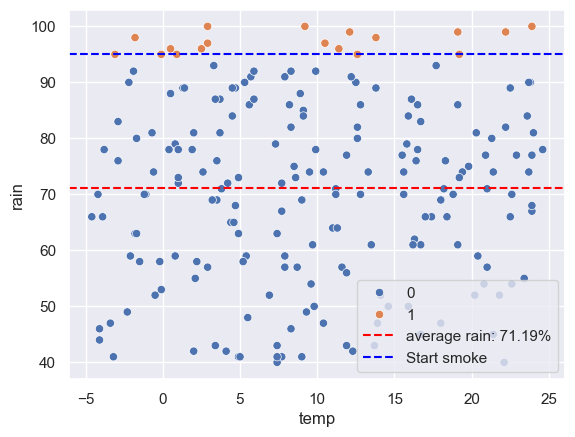

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="darkgrid")
column_names = ["temp","rain","smoke"]
df = pd.read_csv(
    "mist.txt", sep=";",
    header=None, names=column_names
).head(200)
sns.scatterplot(data=df,x="temp",y="rain",hue="smoke")
average_humidity = df["rain"].mean()
plt.axhline(
    y=average_humidity,
    color="red",linestyle="--",
    label=f"average rain: {average_humidity:.2f}%"
)
mist = df[df["smoke"] == 1]
plt.axhline(
    y = mist["rain"].min(),
    color="blue",linestyle="--",
    label="Start smoke"
)
plt.legend()

In [27]:
clusters = [[],[]]
with open ("demo_2025_27_A.txt") as F:
    F.readline()
    for line in F:
        x,y = map(float,line.replace(",",".").split())
        clusters[int(y > 3)].append((x,y))

def getCentroid(cluster):
    minS = float("inf")
    point = (0,0)
    for i in range(len(cluster)-1):
        smDistances = 0
        for j in range(len(cluster)):
            smDistances += dist(cluster[i],cluster[j])
        if smDistances < minS:
            minS = smDistances
            point = cluster[i]
    return point


In [ ]:
clusters = [[],[],[]]
with open ("demo_2025_27_Б.txt") as F:
    F.readline()
    for line in F:
        x,y = map(float,line.replace(",",".").split())
        clusters[int(y > 3)].append((x,y))